In [5]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
input = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')
src = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_output.csv')

In [ ]:
input.head()

,filename,Event,EventTAG,LAT,LON,DEP,LEN_f,WID,Mw,Mo,...,HR-GPS-Data,Hr-GPS-Data,InSAR-Data,Other-Data,SAT-Data,SPOT-Data,hr-GPS-Data,inSAR-Data,level-Data,tril-Data
0,s1906SANFRA01SONG.fsp,San Francisco (Calif.),s1906SANFRA01SONG,37.78,-122.51,10.0,480.0,12.0,7.91,8.150000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s1906SANFRA01THAT.fsp,San Francisco (Calif.),s1906SANFRA01THAT,37.78,-122.51,10.0,480.0,10.0,7.91,8.120000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s1923KANTOJ01KOBA.fsp,Kanto (Japan),s1923KANTOJ01KOBA,35.40,139.20,14.6,130.0,70.0,8.08,1.460000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s1923KANTOJ01WALD.fsp,Kanto (Japan),s1923KANTOJ01WALD,35.40,139.20,14.6,130.0,70.0,7.95,9.330000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s1944TONANK01ICHI.fsp,Tonankai (Japan),s1944TONANK01ICHI,33.77,135.96,30.0,220.0,140.0,8.04,1.310000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Total unique shapes: 271
Most common shape: 3x3 (Count: 24)


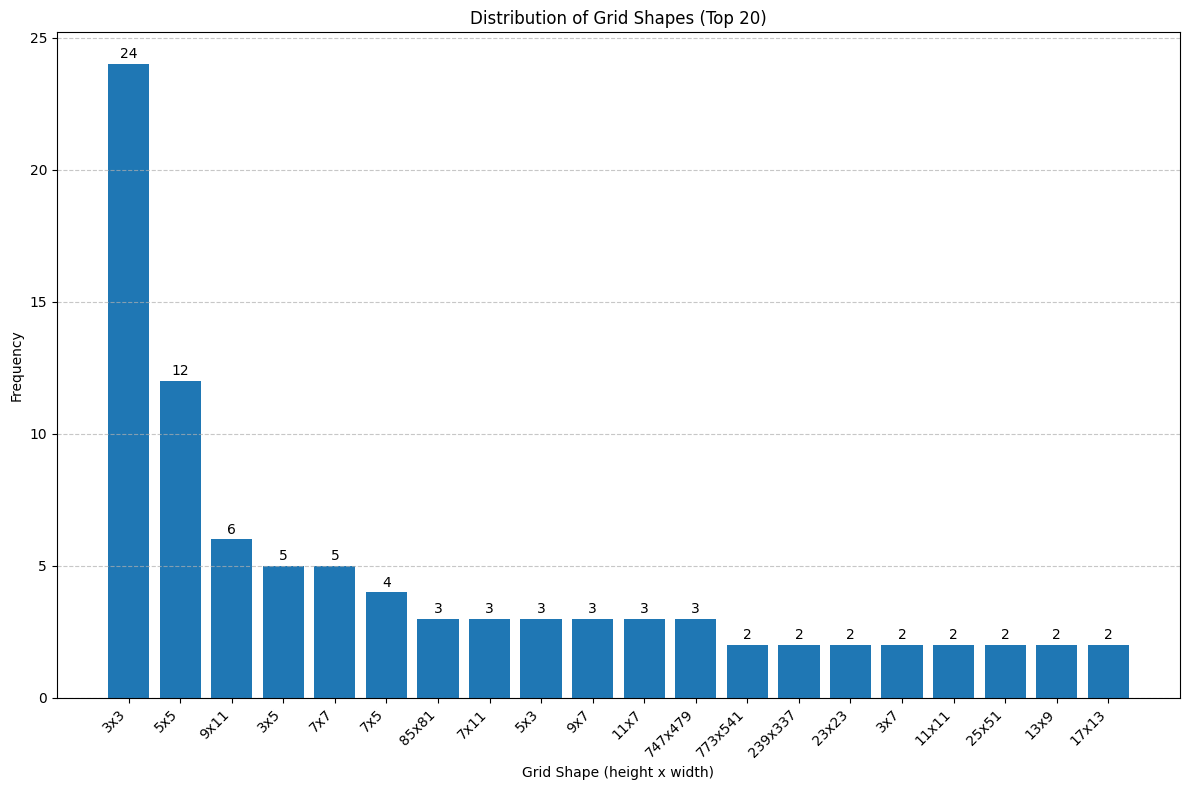

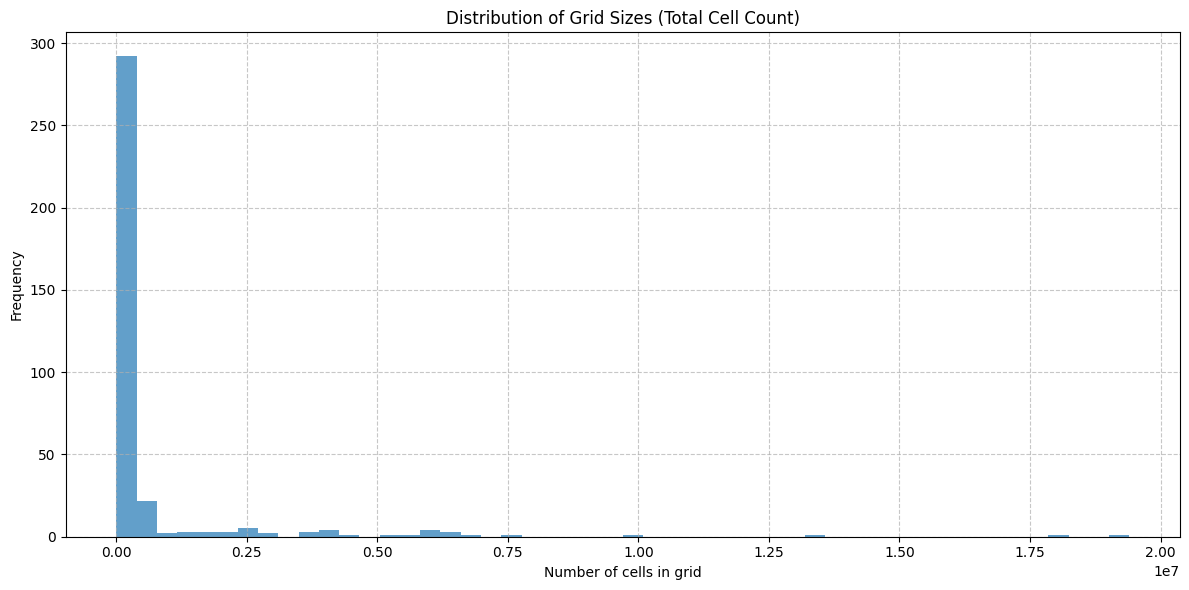

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from collections import Counter

# To store grid shapes 
grid_shapes = []
c=0

for i in src['filename'].unique():
    # Step 1: Load data from CSV
    # Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
    es = src[src['filename']==i]['X==EW'].values * input[input['filename']==i]['Dx'].values[0]/5
    ns = src[src['filename']==i]['Y==NS'].values * input[input['filename']==i]['Dx'].values[0]/5
    slip = src[src['filename']==i]['SLIP'].values/src[src['filename']==i]['SLIP'].max()
    # c+=1
    # print(c)

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Create a meshgrid with integer positions.
    grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                                np.arange(y_min, y_max + 1))
    
    try:
        # Step 4: Interpolate slip values onto the integer grid.
        # Points is an array of the centered (x,y) coordinates.
        points = np.column_stack((es_centered, ns_centered))
        grid_slip = griddata(points, slip, (grid_x, grid_y), method='nearest', fill_value=0)
        
        # Store the shape of grid_slip
        grid_shapes.append(grid_slip.shape)
        
    except Exception as e:
        print(f"Error with {i}: {e}")
        continue

# Convert shapes to strings for better visualization
grid_shape_strs = [f"{shape[0]}x{shape[1]}" for shape in grid_shapes]

# Count occurrences of each shape
shape_counts = Counter(grid_shape_strs)

# Sort by frequency
sorted_shapes = sorted(shape_counts.items(), key=lambda x: x[1], reverse=True)

# Plot the distribution of grid shapes
plt.figure(figsize=(12, 8))
bars = plt.bar([item[0] for item in sorted_shapes[:20]], [item[1] for item in sorted_shapes[:20]])

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}', ha='center', va='bottom', rotation=0)

plt.title('Distribution of Grid Shapes (Top 20)')
plt.xlabel('Grid Shape (height x width)')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Summary statistics
print(f"Total unique shapes: {len(shape_counts)}")
print(f"Most common shape: {sorted_shapes[0][0]} (Count: {sorted_shapes[0][1]})")

# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

# print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")

# Plot the distribution of grid sizes (total number of cells)
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]

plt.figure(figsize=(12, 6))
plt.hist(grid_sizes, bins=50, alpha=0.7)
plt.title('Distribution of Grid Sizes (Total Cell Count)')
plt.xlabel('Number of cells in grid')
plt.ylabel('Frequency')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


In [ ]:
# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")


Largest grid dimensions: 5729x5297
Shape with most cells: 3663x5297 (Total: 19402911 cells)
Average grid size: 620181.2 cells


In [ ]:
slip.min()


np.float64(0.026625258799171842)

In [ ]:
slip.shape

(48,)

In [ ]:
import cv2
import numpy as np

def resize_3d_array(image_array, new_x, new_y):
    """
    Resize a 3D NumPy array along x and y dimensions while interpolating the z-dimension.
    
    Parameters:
        image_array (np.array): Input array of shape (X, Y, Z)
        new_x (int): Desired height
        new_y (int): Desired width
    
    Returns:
        np.array: Resized array of shape (new_x, new_y, Z)
    """
    X, Y, Z = image_array.shape
    resized_slices = [cv2.resize(image_array[:, :, i], (new_y, new_x), interpolation=cv2.INTER_LINEAR) for i in range(Z)]
    resized_array = np.stack(resized_slices, axis=-1)  # Stack along the Z dimension
    
    return resized_array

# Example: Create a 3D NumPy array (e.g., 50x50 with 10 channels)
original_image = np.random.rand(50, 50, 10).astype(np.float32)  # 50x50 image with 10 channels

# Define new shape
new_x, new_y = 100, 100  # Change as needed

# Resize the 3D array
resized_image = resize_3d_array(original_image, new_x, new_y)

# Output shape confirmation
print("Original shape:", original_image.shape)
print("Resized shape:", resized_image.shape)


Original shape: (50, 50, 10)
Resized shape: (100, 100, 10)


In [ ]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 50.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 55.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.5.4
    Uninstalling scipy-1.5.4:
      Successfully uninstalled scipy-1.5.4


In [8]:
import numpy as np

a = np.load(r'./Dataset/slip_arrays_inference/slip_array_s1944TONANK01ICHI.npy')

np.mean(a), np.max(a), np.std(a.flatten())

(np.float64(0.6792882000368675),
 np.float64(2.0981433374869822),
 np.float64(0.5757368201208901))

In [9]:
import numpy as np
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
from skimage.transform import resize

def lat_lon_convert(file_src, file_input, grid_slip):
    # Let's use some example placeholder values

    # df_truth = src[src['filename']==i]
    df_truth = file_src
    Dx = file_input['Dx'].values[0]
    es = file_src['X==EW'].values * Dx/5
    ns = file_src['Y==NS'].values * Dx/5

    slip = file_src['SLIP'].values

    
    # grid_slip = lol
    # Dx = input[input['filename']==i]['Dx'].values[0]
    # es = src[src['filename']==i]['X==EW'].values * Dx/5
    # ns = src[src['filename']==i]['Y==NS'].values * Dx/5

    mean_es= np.mean(es)
    mean_ns= np.mean(ns)
    # --- End of assumed values ---

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Step 1: Recreate the grid of centered coordinates from pixel indices.
    grid_x_centered, grid_y_centered = np.meshgrid(
        np.arange(x_min, x_max + 1),
        np.arange(y_min, y_max + 1)
    )

    points = np.column_stack((es_centered, ns_centered))
    grid_slip_size = griddata(points, slip, (grid_x_centered, grid_y_centered), method='cubic')

    # Reshape grid_slip to match the shape of grid_slip_size
    # grid_slip_size has the shape from the griddata interpolation
    # We need to reshape grid_slip to have the same dimensions
    grid_slip = resize(grid_slip, grid_slip_size.shape,order=3, mode='constant', anti_aliasing=True)



    # Step 2: Reverse the centering by adding the mean back.
    es_grid = grid_x_centered + mean_es
    ns_grid = grid_y_centered + mean_ns

    # Step 3: Reverse the scaling to get the final coordinate grids.
    X_EW_grid = es_grid * (5 / Dx)
    Y_NS_grid = ns_grid * (5 / Dx)



    # --- Process and combine the data for all pixels ---

    # Flatten the 2D grid arrays into 1D arrays.
    # This uses your 'grid_slip' variable.
    x_coords_flat = X_EW_grid.flatten()
    y_coords_flat = Y_NS_grid.flatten()
    slip_values_flat = grid_slip.flatten()

    # Create a Pandas DataFrame to hold the reconstructed data for every pixel.
    df_all_pixels = pd.DataFrame({
        'X_EW': x_coords_flat,
        'Y_NS': y_coords_flat,
        'Interpolated_Slip': slip_values_flat
    })


    # # Display the shape and first few rows to verify the result for the current file.
    # print(f"--- Reconstructed data for file  ---")
    # print(f"DataFrame Shape (rows, columns): {df_all_pixels.shape}")
    # print(df_all_pixels.head())



    # --- Remove rows where 'Interpolated_Slip' is NaN ---
    df_cleaned = df_all_pixels.dropna(subset=['Interpolated_Slip'])


    # print("\n--- DataFrame after removing NaNs ---")
    # print(df_cleaned)
    # print(f"\nShape after: {df_cleaned.shape}")
    # Optionally, you can now save this complete dataset to a file.

    # Assume 'df_cleaned' is your DataFrame from the previous step.
    # It contains the valid, non-NaN grid points from your interpolation.

    # Points from your interpolated grid
    grid_points = df_cleaned[['X_EW', 'Y_NS']].values
    # Slip values corresponding to those grid points
    grid_slip_values = df_cleaned['Interpolated_Slip'].values

    # The locations where you want to sample your grid (the ground truth locations)
    truth_locations = df_truth[['X==EW', 'Y==NS']].values

    # Use griddata to find the interpolated slip values AT the ground truth locations
    # 'nearest' is a good method here to find the value of the closest grid cell.
    slip_at_truth_locations = griddata(grid_points, grid_slip_values, truth_locations, method='nearest')

    # Add these sampled values to your ground truth DataFrame for comparison
    df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


    # Assume 'df_truth' and 'df_cleaned' are already defined in your script.
    # df_truth: Contains the ground truth data linking X/Y to LAT/LON.
    # df_cleaned: Your DataFrame of grid points with X_EW, Y_NS, and slip values.

    # --- Step 1: Prepare the data for interpolation from df_truth ---

    # These are the known coordinate points from your ground truth data.
    points_xy = df_truth[['X==EW', 'Y==NS']].values

    # These are the values we want to interpolate (LAT and LON).
    values_lat = df_truth['LAT'].values
    values_lon = df_truth['LON'].values

    # --- Step 2: Define the points where you want to find LAT and LON ---

    # These are all the pixel coordinates from your cleaned grid.
    points_to_convert = df_cleaned[['X_EW', 'Y_NS']].values

    # --- Step 3: Perform the interpolation for LAT and LON separately ---

    # Interpolate to find the LAT for each point in df_cleaned.
    # 'linear' is a robust method for this kind of spatial conversion.
    lat_interp = griddata(points_xy, values_lat, points_to_convert, method='cubic')

    # Interpolate to find the LON for each point in df_cleaned.
    lon_interp = griddata(points_xy, values_lon, points_to_convert, method='cubic')


    # --- Step 4: Add the new LAT and LON values to your DataFrame ---

    # Create a copy to avoid modifying the original DataFrame in place.
    df_final = df_cleaned.copy()

    # Add the newly calculated LAT and LON as new columns.
    df_final['LAT'] = lat_interp
    df_final['LON'] = lon_interp

    # # --- Display the final result ---
    # print("--- Final DataFrame with LAT and LON for all pixels ---")
    # print(df_final.head(10))
    return df_final.dropna(subset=['LAT', 'LON'])

filename = "s1944TONANK01ICHI.fsp"
grid_slip = np.load(fr"Dataset/slip_arrays_inference/slip_array_{filename[:-4]}.npy")

df_final_ = lat_lon_convert(src[src['filename']==filename], input[input['filename']==filename], grid_slip)

/tmp/ipykernel_517567/608090146.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


In [15]:
def lat_lon_convert_combined(file_src, file_input, grid_slip):
    # Let's use some example placeholder values

    # df_truth = src[src['filename']==i]
    df_truth = file_src
    Dx = file_input['Dx'].values[0]
    es = file_src['X==EW'].values * Dx/5
    ns = file_src['Y==NS'].values * Dx/5

    slip = file_src['SLIP'].values/src[src['filename']]['SLIP'].max()

    
    # grid_slip = lol
    # Dx = input[input['filename']==i]['Dx'].values[0]
    # es = src[src['filename']==i]['X==EW'].values * Dx/5
    # ns = src[src['filename']==i]['Y==NS'].values * Dx/5

    mean_es= np.mean(es)
    mean_ns= np.mean(ns)
    # --- End of assumed values ---

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Step 1: Recreate the grid of centered coordinates from pixel indices.
    grid_x_centered, grid_y_centered = np.meshgrid(
        np.arange(x_min, x_max + 1),
        np.arange(y_min, y_max + 1)
    )

    points = np.column_stack((es_centered, ns_centered))
    grid_slip_size = griddata(points, slip, (grid_x_centered, grid_y_centered), method='cubic')

    # Reshape grid_slip to match the shape of grid_slip_size
    # grid_slip_size has the shape from the griddata interpolation
    # We need to reshape grid_slip to have the same dimensions
    grid_slip = resize(grid_slip, grid_slip_size.shape,order=3, mode='constant', anti_aliasing=True)

    # Step 2: Reverse the centering by adding the mean back.
    es_grid = grid_x_centered + mean_es
    ns_grid = grid_y_centered + mean_ns

    # Step 3: Reverse the scaling to get the final coordinate grids.
    X_EW_grid = es_grid * (5 / Dx)
    Y_NS_grid = ns_grid * (5 / Dx)



    # --- Process and combine the data for all pixels ---

    # Flatten the 2D grid arrays into 1D arrays.
    # This uses your 'grid_slip' variable.
    x_coords_flat = X_EW_grid.flatten()
    y_coords_flat = Y_NS_grid.flatten()
    slip_values_flat = grid_slip.flatten()

    # Create a Pandas DataFrame to hold the reconstructed data for every pixel.
    df_all_pixels = pd.DataFrame({
        'X_EW': x_coords_flat,
        'Y_NS': y_coords_flat,
        'Interpolated_Slip': slip_values_flat
    })


    # # Display the shape and first few rows to verify the result for the current file.
    # print(f"--- Reconstructed data for file  ---")
    # print(f"DataFrame Shape (rows, columns): {df_all_pixels.shape}")
    # print(df_all_pixels.head())



    # --- Remove rows where 'Interpolated_Slip' is NaN ---
    df_cleaned = df_all_pixels.dropna(subset=['Interpolated_Slip'])


    # print("\n--- DataFrame after removing NaNs ---")
    # print(df_cleaned)
    # print(f"\nShape after: {df_cleaned.shape}")
    # Optionally, you can now save this complete dataset to a file.

    # Assume 'df_cleaned' is your DataFrame from the previous step.
    # It contains the valid, non-NaN grid points from your interpolation.

    # Points from your interpolated grid
    grid_points = df_cleaned[['X_EW', 'Y_NS']].values
    # Slip values corresponding to those grid points
    grid_slip_values = df_cleaned['Interpolated_Slip'].values

    # The locations where you want to sample your grid (the ground truth locations)
    truth_locations = df_truth[['X==EW', 'Y==NS']].values

    # Use griddata to find the interpolated slip values AT the ground truth locations
    # 'nearest' is a good method here to find the value of the closest grid cell.
    slip_at_truth_locations = griddata(grid_points, grid_slip_values, truth_locations, method='nearest')

    # Add these sampled values to your ground truth DataFrame for comparison
    df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


    # Assume 'df_truth' and 'df_cleaned' are already defined in your script.
    # df_truth: Contains the ground truth data linking X/Y to LAT/LON.
    # df_cleaned: Your DataFrame of grid points with X_EW, Y_NS, and slip values.

    # --- Step 1: Prepare the data for interpolation from df_truth ---

    # These are the known coordinate points from your ground truth data.
    points_xy = df_truth[['X==EW', 'Y==NS']].values

    # These are the values we want to interpolate (LAT and LON).
    values_lat = df_truth['LAT'].values
    values_lon = df_truth['LON'].values

    # --- Step 2: Define the points where you want to find LAT and LON ---

    # These are all the pixel coordinates from your cleaned grid.
    points_to_convert = df_cleaned[['X_EW', 'Y_NS']].values

    # --- Step 3: Perform the interpolation for LAT and LON separately ---

    # Interpolate to find the LAT for each point in df_cleaned.
    # 'linear' is a robust method for this kind of spatial conversion.
    lat_interp = griddata(points_xy, values_lat, points_to_convert, method='cubic')

    # Interpolate to find the LON for each point in df_cleaned.
    lon_interp = griddata(points_xy, values_lon, points_to_convert, method='cubic')


    # --- Step 4: Add the new LAT and LON values to your DataFrame ---

    # Create a copy to avoid modifying the original DataFrame in place.
    df_final = df_cleaned.copy()

    # Add the newly calculated LAT and LON as new columns.
    df_final['LAT'] = lat_interp
    df_final['LON'] = lon_interp

    # --- NEW: Add ground truth slip interpolation ---
    # Interpolate ground truth slip values onto the same grid points
    ground_truth_slip_values = df_truth['SLIP'].values
    ground_truth_slip_interp = griddata(points_xy, ground_truth_slip_values, points_to_convert, method='cubic')
    
    # Add ground truth slip as a new column
    df_final['Ground_Truth_Slip'] = ground_truth_slip_interp

    # # --- Display the final result ---
    # print("--- Final DataFrame with LAT and LON for all pixels ---")
    # print(df_final.head(10))
    return df_final.dropna(subset=['LAT', 'LON'])


filename = "s1944TONANK01ICHI.fsp"
grid_slip = np.load(fr"Dataset/slip_arrays_inference/slip_array_{filename[:-4]}.npy")

df_final_ = lat_lon_convert_combined(src[src['filename']==filename], input[input['filename']==filename], grid_slip)


KeyError: "None of [Index(['s1906SANFRA01SONG.fsp', 's1906SANFRA01SONG.fsp',\n       's1906SANFRA01SONG.fsp', 's1906SANFRA01SONG.fsp',\n       's1906SANFRA01SONG.fsp', 's1906SANFRA01SONG.fsp',\n       's1906SANFRA01SONG.fsp', 's1906SANFRA01SONG.fsp',\n       's1906SANFRA01SONG.fsp', 's1906SANFRA01SONG.fsp',\n       ...\n       's2020SAMOSx01PLIC.fsp', 's2020SAMOSx01PLIC.fsp',\n       's2020SAMOSx01PLIC.fsp', 's2020SAMOSx01PLIC.fsp',\n       's2020SAMOSx01PLIC.fsp', 's2020SAMOSx01PLIC.fsp',\n       's2020SAMOSx01PLIC.fsp', 's2020SAMOSx01PLIC.fsp',\n       's2020SAMOSx01PLIC.fsp', 's2020SAMOSx01PLIC.fsp'],\n      dtype='object', length=130935)] are in the [columns]"

In [12]:
df_final_

,X_EW,Y_NS,Interpolated_Slip,LAT,LON,Ground_Truth_Slip
2093,42.73144,-95.851443,0.127832,32.907434,136.422617,1.079009
2094,42.98144,-95.851443,0.127927,32.907434,136.425323,1.076038
2095,43.23144,-95.851443,0.128115,32.907434,136.428029,1.073166
3010,42.73144,-95.601443,0.141128,32.909683,136.422616,1.084721
3011,42.98144,-95.601443,0.141250,32.909683,136.425322,1.081770
...,...,...,...,...,...,...
759015,141.98144,110.398557,0.091847,34.763515,137.497076,1.010374
759016,142.23144,110.398557,0.090106,34.763514,137.499783,1.002445
759931,141.73144,110.648557,0.084445,34.765766,137.494369,1.014836
759932,141.98144,110.648557,0.082911,34.765765,137.497076,1.006791


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# First, remove any rows where LAT or LON are NaN, as these cannot be plotted.
df_plot = df_final_.dropna(subset=['LAT', 'LON'])

# Create a single map showing only the interpolated slip values
fig = go.Figure()

# Add interpolated slip scatter plot
fig.add_trace(
    go.Scattermapbox(
        lat=df_plot['LAT'],
        lon=df_plot['LON'],
        mode='markers',
        marker=dict(
            size=df_plot['Interpolated_Slip'] * 10,  # Scale size for visibility
            color=df_plot['Interpolated_Slip'],
            colorscale='Viridis',
            sizemode='diameter',
            sizemin=2,
            sizemax=20,
            colorbar=dict(title="Interpolated Slip")
        ),
        text=df_plot['Interpolated_Slip'],
        hovertemplate='<b>Interpolated Slip</b>: %{text:.4f}<br>' +
                      '<b>Lat</b>: %{lat:.4f}<br>' +
                      '<b>Lon</b>: %{lon:.4f}<extra></extra>',
        name="Interpolated Slip"
    )
)

# Update mapbox settings
fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        zoom=8,
        center=dict(lat=df_plot['LAT'].mean(), lon=df_plot['LON'].mean())
    ),
    title="Predicted Slip Values",
    margin={"r":0,"t":60,"l":0,"b":0},
    height=600,
    width=800
)

fig.show()


ValueError: Invalid property specified for object of type plotly.graph_objs.scattermapbox.Marker: 'sizemax'

Did you mean "sizemin"?

    Valid properties:
        allowoverlap
            Flag to draw all symbols, even if they overlap.
        angle
            Sets the marker orientation from true North, in degrees
            clockwise. When using the "auto" default, no rotation
            would be applied in perspective views which is
            different from using a zero angle.
        anglesrc
            Sets the source reference on Chart Studio Cloud for
            `angle`.
        autocolorscale
            Determines whether the colorscale is a default palette
            (`autocolorscale: true`) or the palette determined by
            `marker.colorscale`. Has an effect only if in
            `marker.color` is set to a numerical array. In case
            `colorscale` is unspecified or `autocolorscale` is
            true, the default palette will be chosen according to


In [2]:
!pip install plotly

  Using cached plotly-6.3.1-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.3.1-py3-none-any.whl (9.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')


# Define the categories for Mw values
bins = [0, 5.9, 6.9, float('inf')]
labels = ['Minor-Moderate (Mw < 6.0)', 'Strong (6.0 <= Mw < 7.0)', 'Major (Mw >= 7.0)']
df['Mw_category'] = pd.cut(df['Mw'], bins=bins, labels=labels, right=False)

# Create the interactive map
fig = px.scatter_geo(df,
                    lat='LAT',
                    lon='LON',
                    color='Mw_category',
                    size='Mw',
                    hover_name='Mw_category',
                    hover_data={'LAT': True, 'LON': True, 'Mw': True, 'Mw_category': False},
                    projection="natural earth",
                    title="Interactive Map of Earthquake Locations",
                    color_discrete_map={
                        'Minor-Moderate (Mw < 6.0)': 'green',
                        'Strong (6.0 <= Mw < 7.0)': 'orange',
                        'Major (Mw >= 7.0)': 'red'
                    },
                    category_orders={"Mw_category": labels} # Ensures legend is in the correct order
                   )

fig.show()

ModuleNotFoundError: No module named 'cartopy'

In [6]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 1.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [cartopy]m3/4 [cartopy]


/home/kaushik/miniconda3/lib/python3.13/site-packages/cartopy/io/img_tiles.py:414: UserWarning:

The Stamen styles are no longer served by Stamen and are now served by Stadia Maps. Please use the StadiaMapsTiles class instead.



<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not known>
<urlopen error [Errno -2] Name or service not 

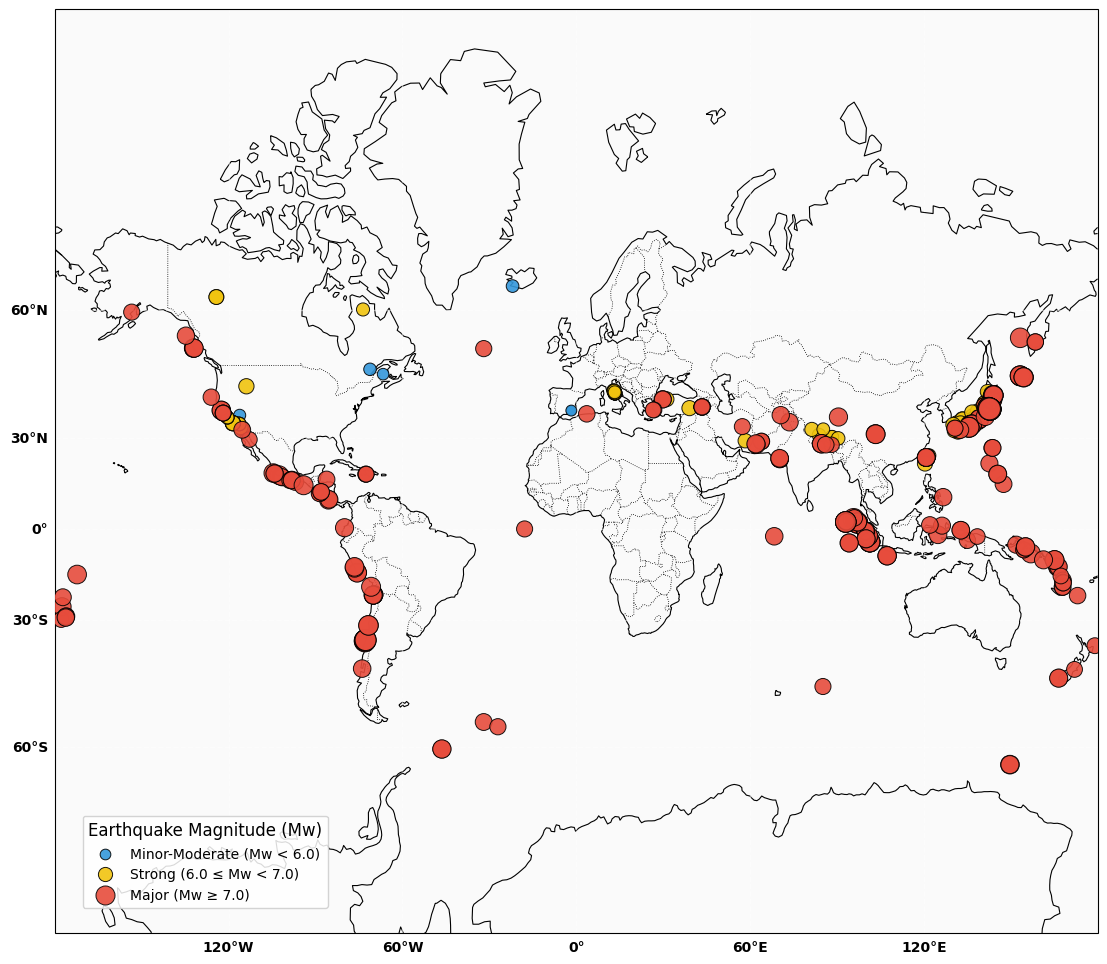

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. Load and Prepare Data ---
try:
    df = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')
except FileNotFoundError:
    print("Error: The specified CSV file was not found.")
    exit()

# --- 2. Categorize Earthquake Magnitudes ---
# Define the magnitude bins and labels for categorization.
bins = [0, 5.9, 6.9, float('inf')]
labels = ['Minor-Moderate (Mw < 6.0)', 'Strong (6.0 ≤ Mw < 7.0)', 'Major (Mw ≥ 7.0)']
df['Mw_category'] = pd.cut(df['Mw'], bins=bins, labels=labels, right=False)

# --- 3. Define Map Aesthetics ---
# Define a color map for the categories.
color_map = {
    'Minor-Moderate (Mw < 6.0)': '#3498db',  # Blue
    'Strong (6.0 ≤ Mw < 7.0)': '#f1c40f',  # Yellow
    'Major (Mw ≥ 7.0)': '#e74c3c'      # Red
}

# --- 4. Create the Map Figure ---
# Use a suitable projection like Robinson, which is available in most Cartopy versions.
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson()) # <-- CORRECTED LINE
ax.set_global()

# --- 5. Add Geographical Features for Context ---
# Add high-resolution coastlines, country borders, and shaded land/ocean.
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='#d9d9d9')
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#b3d1ff')
ax.add_feature(cfeature.COASTLINE, zorder=1, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, zorder=1, linestyle=':', linewidth=0.6)

# Add gridlines (graticules) for geographic reference.
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}


# --- 6. Plot the Earthquake Data ---
# Use a loop to plot each category for precise legend control.
legend_elements = []
for category in labels:
    subset = df[df['Mw_category'] == category]
    # Scale marker size by magnitude for better visual impact.
    scatter = ax.scatter(subset['LON'], subset['LAT'],
                         s=subset['Mw']**2.5,
                         c=color_map[category],
                         label=category,
                         alpha=0.8,
                         edgecolors='k',
                         linewidth=0.5,
                         transform=ccrs.PlateCarree(), # Specify data's coordinate system
                         zorder=10)
    legend_elements.append(scatter)


# --- 7. Add and Customize the Legend ---
# Create a clear, well-placed legend.
legend = ax.legend(handles=legend_elements,
                   title='Earthquake Magnitude (Mw)',
                   loc='lower left',
                   bbox_to_anchor=(0.02, 0.02),
                   frameon=True,
                   fontsize=10,
                   title_fontsize=12)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.8)

# --- 8. Save the Figure for Publication ---
# Save the map in a high-resolution format.
plt.savefig('publication_earthquake_map.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.savefig('publication_earthquake_map.pdf', bbox_inches='tight', pad_inches=0.2)

print("Map has been saved as 'publication_earthquake_map.png' and 'publication_earthquake_map.pdf'")

plt.show()

In [16]:
!pip install contextily
!pip install matplotlib_scalebar

/home/kaushik/miniconda3/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:842: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.

/home/kaushik/miniconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip

/home/kaushik/miniconda3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip



Map has been saved as 'publication_map_python.png' and 'publication_map_python.pdf'


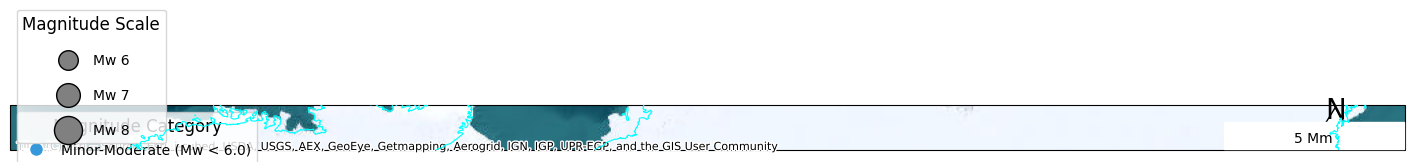

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

# --- 1. Load and Prepare Data ---
try:
    df = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')
except FileNotFoundError:
    print("Error: The specified CSV file was not found. Please ensure the path is correct.")
    exit()

# --- 2. Categorize Earthquake Magnitudes ---
bins = [0, 5.9, 6.9, float('inf')]
labels = ['Minor-Moderate (Mw < 6.0)', 'Strong (6.0 ≤ Mw < 7.0)', 'Major (Mw ≥ 7.0)']
df['Mw_category'] = pd.cut(df['Mw'], bins=bins, labels=labels, right=False)

# --- 3. Define Map Aesthetics ---
# A colorblind-friendly and visually distinct color palette
color_map = {
    'Minor-Moderate (Mw < 6.0)': '#3498db',  # Blue
    'Strong (6.0 ≤ Mw < 7.0)': '#f1c40f',  # Yellow
    'Major (Mw ≥ 7.0)': '#e74c3c'      # Red
}
df['color'] = df['Mw_category'].map(color_map)

# --- 4. Create the Map Figure in the Correct Projection ---
# Basemaps from contextily are in Web Mercator projection (EPSG:3857)
# We must create our plot in this projection.
fig, ax = plt.subplots(figsize=(18, 12), subplot_kw={'projection': ccrs.Mercator()})

# Set the geographic extent [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([-180, 180, -75, 85], crs=ccrs.PlateCarree())

# --- 5. Plot the Earthquake Data ---
# We plot the data first, then add the basemap on top.
# The data's CRS is PlateCarree (lat/lon), and we transform it to the map's Mercator projection.
ax.scatter(df['LON'], df['LAT'],
           s=df['Mw']**2.5,          # Scale marker size by magnitude
           c=df['color'],
           alpha=0.8,
           edgecolors='black',      # Black outline makes points stand out
           linewidth=0.5,
           transform=ccrs.PlateCarree(),
           zorder=10) # Ensure points are on top of other layers

# --- 6. Add a High-Quality Satellite Basemap ---
# Contextily adds the basemap, automatically matching the plot's extent and projection.
# Esri.WorldImagery is an excellent choice for a clean satellite view.
# You can experiment with others, e.g., ctx.providers.Esri.WorldShadedRelief
ctx.add_basemap(ax,
                source=ctx.providers.Esri.WorldImagery,
                zoom='auto') # Let contextily choose the best zoom level

# --- 7. Add Contextual Geographical Features ---
# Add crisp coastlines and borders on top of the satellite imagery for clarity.
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='cyan', zorder=11)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6, edgecolor='cyan', zorder=11)


# --- 8. Build a Professional, Composite Legend ---
# This is a crucial step for a high-quality map. We create a legend
# that explains both the color categories and the size scaling.

# Part A: Legend for Color Categories
legend_elements_color = [
    Line2D([0], [0], marker='o', color='w', label=labels[0], markerfacecolor=color_map[labels[0]], markersize=10),
    Line2D([0], [0], marker='o', color='w', label=labels[1], markerfacecolor=color_map[labels[1]], markersize=10),
    Line2D([0], [0], marker='o', color='w', label=labels[2], markerfacecolor=color_map[labels[2]], markersize=10)
]
legend1 = ax.legend(handles=legend_elements_color,
                    title='Magnitude Category',
                    loc='upper left',
                    frameon=True,
                    framealpha=0.8,
                    facecolor='white',
                    fontsize=10,
                    title_fontsize=12)
ax.add_artist(legend1) # We must add the first legend manually before creating a second one.

# Part B: Legend for Size Scaling
size_magnitudes = [6, 7, 8]
legend_elements_size = [
    Line2D([0], [0], marker='o', color='none', label=f'Mw {mag}',
           markerfacecolor='gray', markeredgecolor='k', markersize=mag**1.25 * 1.5) # Scale marker size for legend
    for mag in size_magnitudes
]
legend2 = ax.legend(handles=legend_elements_size,
                    title='Magnitude Scale',
                    loc='lower left',
                    frameon=True,
                    framealpha=0.8,
                    facecolor='white',
                    labelspacing=1.5, # Increase spacing for different sized markers
                    fontsize=10,
                    title_fontsize=12)


# --- 9. Add a Scale Bar and North Arrow ---

# Add a scale bar. The dx unit is based on the projection (meters for Mercator).
ax.add_artist(ScaleBar(dx=1, units='m', location='lower right'))

# Add a simple North arrow
x, y, arrow_length = 0.95, 0.95, 0.07
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='white', edgecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=20, color='black',
            xycoords=ax.transAxes)


# --- 10. Save the Final Figure ---
# Save in high DPI for publication. PDF is a vector format, which is ideal.
plt.savefig('publication_map_python.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.savefig('publication_map_python.pdf', bbox_inches='tight', pad_inches=0.1)

print("Map has been saved as 'publication_map_python.png' and 'publication_map_python.pdf'")

plt.show()